Mapping of Group Code to Group code text


In [4]:
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

df = pd.read_csv("/content/MDS_20220401_20230531_20230705_171405.csv", dtype={'Group code': str})

mapping = defaultdict(lambda: defaultdict(set))

for _, row in df.iterrows():
    gc = row['Group code'].zfill(2)

    text = str(row['Group code text']).strip().lower()
    words = text.replace('.', ' ').split()

    if len(gc) != len(words):
        continue

    for i in range(len(gc)):
        digit = gc[i]
        word = words[i].capitalize()

        mapping[i][digit].add(word)

for pos, values in mapping.items():
    print(f"\nPosition {pos+1}:")
    for digit, word in sorted(values.items()):
        print(f"{digit} → {word}")


Position 1:
0 → {'Comn', 'Common', 'Operation'}
1 → {'Bwe'}
2 → {'Mtc'}
3 → {'Tf', 'Opr', 'Planned'}
4 → {'Con', 'Conveyor', 'Opr'}
5 → {'Tripper'}
6 → {'Spreader'}
7 → {'Stacker'}
8 → {'Reclaimer'}
9 → {'Unplanned'}

Position 2:
0 → {'Stoppages', 'Tf', 'Con', 'Opr', 'Operation'}
1 → {'Mm'}
2 → {'Mrr'}
3 → {'Oh'}
4 → {'Vulcanising', 'Vulcansing'}
5 → {'Cmm'}
6 → {'Cmrr', 'Planned'}
7 → {'Miscellaneous'}
8 → {'Electrical'}
9 → {'Others', 'Other', 'Sme'}


Machine wise Downtime

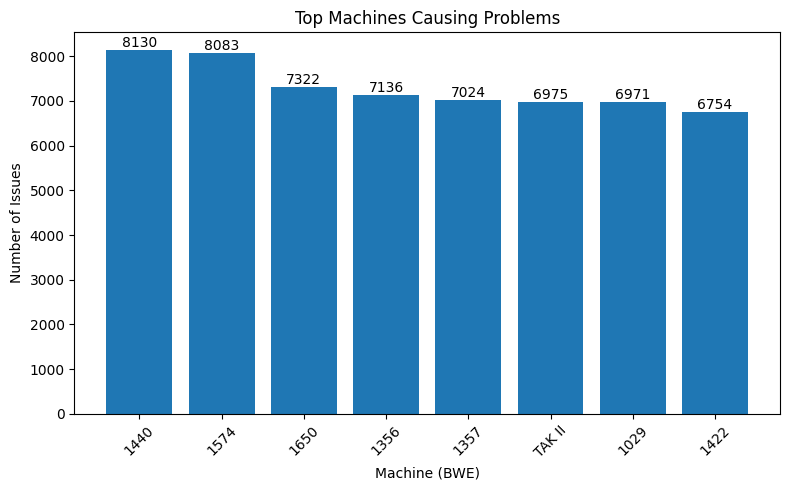


=== Top Issues per Machine ===

   BWE      Group code text                                          Remarks  Count
  1650        Bwe Operation                       Bwe Track Area Preparation   1484
  1440     Common Operation                                    Bottom Dozing   1156
TAK II        Bwe Operation                       Bwe Track Area Preparation    786
  1574     Common Operation           M/C Movement For Lignite Conv.Loading.    774
  1356     Common Operation                                    Bottom Dozing    662
  1029     Common Operation           M/C Movement For Lignite Conv.Loading.    605
  1357    Planned Operation                                Daily Maintenance    601
  1650    Planned Operation                                Daily Maintenance    589
  1440    Planned Operation                                Daily Maintenance    574
  1422        Bwe Operation                       Bwe Track Area Preparation    568
  1574     Common Operation                

In [5]:


df = df.dropna(subset=['BWE', 'Group code text', 'Remarks'])

df['BWE'] = df['BWE'].astype(str).str.strip()
df['Group code text'] = df['Group code text'].astype(str).str.strip().str.title()
df['Remarks'] = df['Remarks'].astype(str).str.strip().str.title()

counts_Mac = df['BWE'].value_counts()
top_counts_Mac = counts_Mac.head(8)

plt.figure(figsize=(8,5))
bars = plt.bar(top_counts_Mac.index, top_counts_Mac.values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Top Machines Causing Problems")
plt.xlabel("Machine (BWE)")
plt.ylabel("Number of Issues")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_machines = top_counts_Mac.index
df_top = df[df['BWE'].isin(top_machines)]

analysis = (
    df_top
    .groupby(['BWE', 'Group code text', 'Remarks'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
)

top5_per_machine = (
    analysis
    .groupby('BWE')
    .head(5)
    .reset_index(drop=True)
)

print("\n=== Top Issues per Machine ===\n")
print(top5_per_machine.to_string(index=False))




Climate wise Downtime


Machine wise Downtime

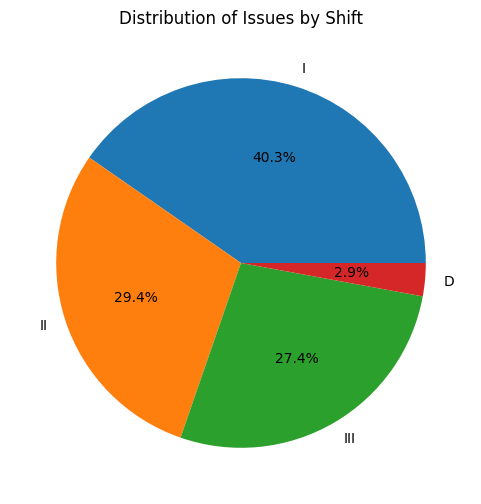

In [6]:



df = df.dropna(subset=['Shift'])

df['Shift'] = df['Shift'].astype(str).str.strip()

shift_counts = df['Shift'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(shift_counts, labels=shift_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Issues by Shift")
plt.show()

AVG Downtime

In [7]:
summary = df.groupby('BWE').agg({
    'Duration': 'sum',
    'BWE': 'count'
}).rename(columns={'BWE': 'Failure Count'})

summary['Avg Downtime'] = summary['Duration'] / summary['Failure Count']

print(summary.sort_values(by='Duration', ascending=False))


         Duration  Failure Count  Avg Downtime
BWE                                           
1231     18675.90           1447     12.906634
1420     17798.20           2452      7.258646
1137     14837.70           1745      8.502980
REC      14775.05           3183      4.641863
146      11999.80           2046      5.865005
1355     11543.60           4810      2.399917
1571     11204.80           5585      2.006231
1198     10888.80           3043      3.578311
1145     10555.30           2580      4.091202
1422     10164.15           6754      1.504908
1421     10063.95           6061      1.660444
REC2     10011.00           5425      1.845346
TAK II    9658.20           6975      1.384688
TAK I     9430.15           6113      1.542639
L&T 6     9407.50           5971      1.575532
1448      9399.95           5745      1.636197
147       9349.45           5763      1.622323
L&T 5     9273.95           6129      1.513126
L&T 1     9200.40           4940      1.862429
L&T 2     910

Plant wise Downtime

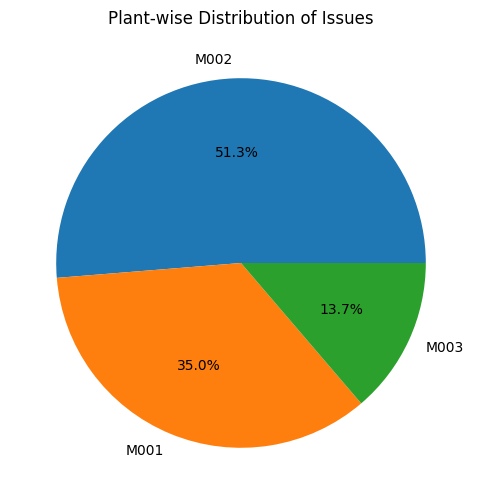

In [8]:


df = df.dropna(subset=['Plant'])

df['Plant'] = df['Plant'].astype(str).str.strip()

plant_counts = df['Plant'].value_counts()

top_plants = plant_counts.head(8)

plt.figure(figsize=(6,6))
plt.pie(top_plants, labels=top_plants.index, autopct='%1.1f%%')

plt.title("Plant-wise Distribution of Issues")
plt.show()

Material wise Downtime

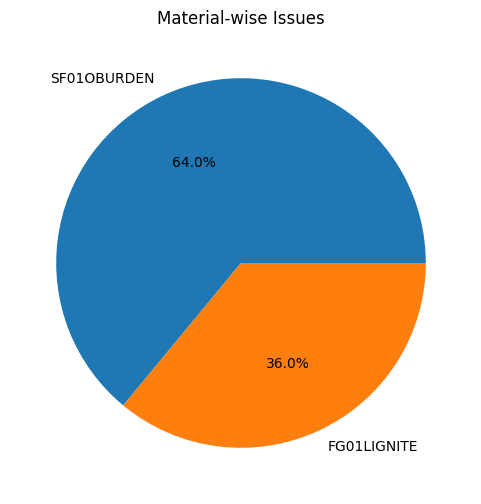

In [9]:


df = df.dropna(subset=['Material Number'])

df['Material Number'] = df['Material Number'].astype(str).str.strip()

Material_counts = df['Material Number'].value_counts()

top_material = Material_counts.head(8)

plt.figure(figsize=(6,6))
plt.pie(top_material, labels=top_material.index, autopct='%1.1f%%')

plt.title("Material-wise Issues")
plt.show()

Top 10 Downtime

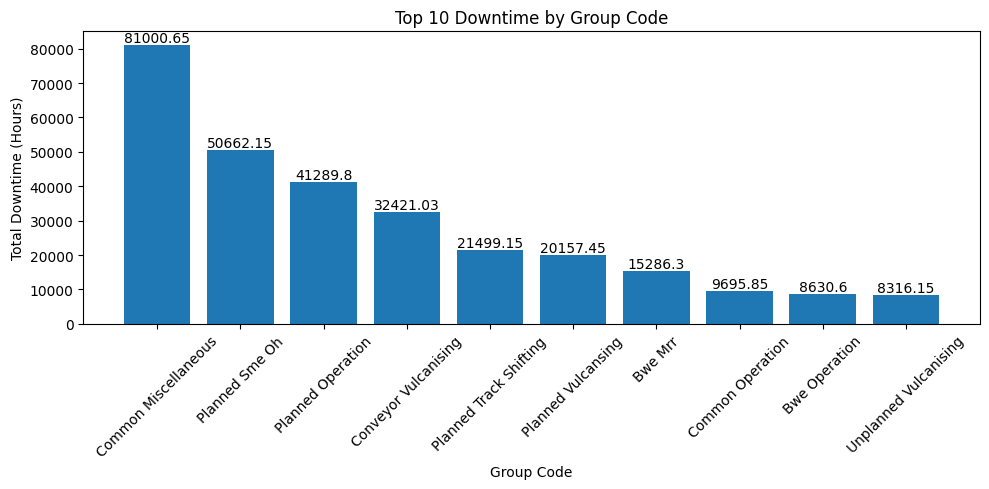

In [10]:
df = df.dropna(subset=['Group code text', 'Duration'])

df['Group code text'] = df['Group code text'].astype(str).str.strip()

group_downtime = df.groupby('Group code text')['Duration'].sum()

top10 = group_downtime.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10.index, top10.values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,2),
             ha='center', va='bottom')

plt.title("Top 10 Downtime by Group Code")
plt.xlabel("Group Code")
plt.ylabel("Total Downtime (Hours)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



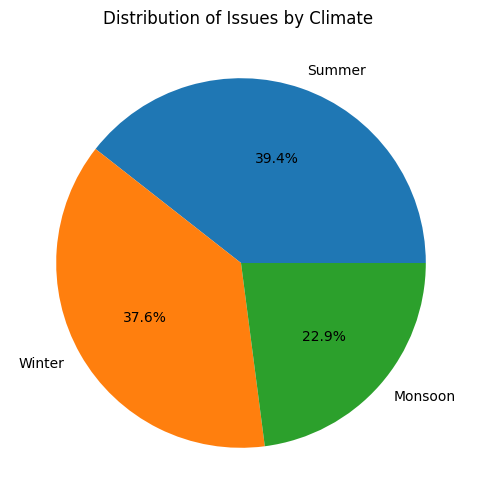

    Climate   BWE  Count
13  Monsoon  1440   2227
46   Summer  1356   3284
97   Winter  1574   3355


In [15]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df['Month'] = df['Date'].dt.month

def get_climate(month):
    if month in [3,4,5,6]:
        return "Summer"
    elif month in [7,8,9]:
        return "Monsoon"
    else:
        return "Winter"

df['Climate'] = df['Month'].apply(get_climate)

climate_counts = df['Climate'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(climate_counts, labels=climate_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Issues by Climate ")
plt.show()

climate_machine = df.groupby(['Climate','BWE']).size().reset_index(name='Count')

top_machine = climate_machine.loc[
    climate_machine.groupby('Climate')['Count'].idxmax()
]

print(top_machine)

